# 11 — Heat Risk with Adaptive Capacity: Three-City Comparison

Notebook 10 established that household income from the 2022 Brazilian census is a
meaningful **adaptive capacity** proxy for Salvador.  The core argument is that income
mediates a resident's ability to cope when heat occurs — affording air conditioning,
accessing healthcare, taking time off outdoor work — regardless of whether poorer
neighbourhoods are physically hotter.

This notebook extends the framework to **all three study cities** (Salvador, Teresina,
Cáceres) and produces a revised heat risk function that explicitly incorporates adaptive
capacity.  It then makes concrete recommendations for implementation and documents
shortcomings, assumptions, and future directions.

**Income data sources (2022 IBGE Census):**
| City | File | Census sectors | Nulls dropped |
|------|------|---------------|---------------|
| Salvador | `renda_responsavel_2927408_...geojson` | 4 542 | 66 |
| Teresina | `renda_responsavel_2211001_...geojson` | 1 531 | 38 |
| Cáceres  | `renda_responsavel_5102504_...geojson` | 213  | 13 |

> **Scaling caveat (read before interpreting results):** `renda_responsavel` is a
> Brazilian census variable.  The composite index constructed here is a
> **within-city, within-Brazil ranking tool only**.  Income data at comparable spatial
> resolution does not exist for most countries, and even where it does, raw income
> values are not comparable across national contexts due to differences in purchasing
> power, housing markets, and the income–adaptive capacity relationship.  See Section 6
> for global alternatives.

**Prerequisites:** `01_data_acquisition`, `02_compute_baselines`, `10_income_spatial_layer`.

## Setup

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import geopandas as gpd
from scipy.stats import spearmanr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES, load_city, load_tx90p_threshold, load_neighbourhood_boundaries,
    compute_absolute_heat_days, compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
)

DATA_DIR      = 'data'
DIAG_YEAR     = 2020
ABS_THRESHOLD = 30.0
PERCENTILE    = 90
CITY_KEYS     = ['salvador', 'teresina', 'caceres']

# Per-city SIRGAS 2000 UTM projected CRS for accurate centroid computation
PROJ_CRS = {
    'salvador': 'EPSG:31984',  # UTM zone 24S
    'teresina': 'EPSG:31983',  # UTM zone 23S
    'caceres':  'EPSG:31981',  # UTM zone 21S
}

INCOME_FILES = {
    'salvador': 'data/renda_responsavel_2927408_georedus_censo_2022.geojson',
    'teresina': 'data/renda_responsavel_2211001_georedus_censo_2022.geojson',
    'caceres':  'data/renda_responsavel_5102504_georedus_censo_2022.geojson',
}

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th',      'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td',      'props': 'text-align:center; font-size:0.85em;'},
]

def load_pop_grid(city, year):
    import xarray as xr
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

def count_doy_exceedances(da, thresh_doy):
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > aligned).resample(time='YS').sum(dim='time')

def cv(s):
    return s.std() / s.mean() if s.mean() != 0 else np.nan

## Section 1 — Income aggregation: census sectors → neighbourhood boundaries

Each census sector polygon is projected to the appropriate SIRGAS 2000 UTM zone for
its city, reduced to its centroid, and assigned to the neighbourhood polygon containing
it.  Income per neighbourhood is the **simple mean** of all sector incomes whose
centroids fall inside that polygon.  Any unmatched centroid (e.g. a coastal sector
clipped outside all polygons) is assigned to the nearest neighbourhood by Euclidean
distance in the projected CRS.

The ideal approach would be to work directly with income estimates published at the
same neighbourhood level used for prioritisation, avoiding the aggregation step
entirely.  The centroid method is a practical approximation given the data available;
its limitations are documented in Section 6.

In [4]:
def aggregate_income(city_key, districts):
    """Aggregate census sector income to neighbourhood boundaries via centroid join."""
    income_raw = gpd.read_file(INCOME_FILES[city_key])
    income_gdf = income_raw.dropna(subset=['renda_responsavel']).reset_index(drop=True)
    n_dropped  = len(income_raw) - len(income_gdf)

    proj = PROJ_CRS[city_key]
    income_proj    = income_gdf.to_crs(proj)
    districts_proj = districts.to_crs(proj)

    pts = income_proj[['id', 'renda_responsavel']].copy()
    pts['geometry'] = income_proj.geometry.centroid
    pts = gpd.GeoDataFrame(pts, crs=proj)

    joined = gpd.sjoin(pts, districts_proj[['name', 'geometry']],
                       how='left', predicate='within')

    unmatched = joined['name'].isna().sum()
    if unmatched > 0:
        unmatched_idx = joined.index[joined['name'].isna()]
        nearest = gpd.sjoin_nearest(
            pts.loc[unmatched_idx],
            districts_proj[['name', 'geometry']],
            how='left',
        )
        # sjoin_nearest can return duplicate rows when distances are tied — keep first
        nearest = nearest[~nearest.index.duplicated(keep='first')]
        joined.loc[unmatched_idx, 'name'] = nearest['name']

    result = (
        joined.groupby('name')['renda_responsavel']
        .agg(mean_income='mean', n_sectors='count', std_income='std')
        .reset_index()
    )

    print(f"{CITIES[city_key]['label']:12s}  "
          f"sectors: {len(income_gdf)} (dropped {n_dropped} nulls)  "
          f"unmatched centroids: {unmatched}  "
          f"neighbourhoods covered: {len(result)}/{len(districts)}")

    return result


districts = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}
income    = {}
print("Income aggregation summary")
print("-" * 70)
for c in CITY_KEYS:
    income[c] = aggregate_income(c, districts[c])

Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg
Income aggregation summary
----------------------------------------------------------------------
Salvador, Brazil  sectors: 4476 (dropped 66 nulls)  unmatched centroids: 0  neighbourhoods covered: 22/22
Teresina, Brazil  sectors: 1493 (dropped 38 nulls)  unmatched centroids: 198  neighbourhoods covered: 112/112
Cáceres, Brazil  sectors: 200 (dropped 13 nulls)  unmatched centroids: 54  neighbourhoods covered: 43/43


## Section 2 — Heat and population metrics (TX90p, 2020)

Replicates the neighbourhood-level aggregation from notebook 07 for all three cities.

In [5]:
import xarray as xr

def build_heat_table(city_key):
    da       = load_city(city_key, DATA_DIR)
    da.attrs['units'] = 'degC'
    thresh   = load_tx90p_threshold(city_key, DATA_DIR)
    pop_grid = load_pop_grid(city_key, DIAG_YEAR)
    gdf      = districts[city_key]

    abs_hd   = compute_absolute_heat_days(da, DIAG_YEAR, ABS_THRESHOLD)
    tx_annual = count_doy_exceedances(da, thresh.sel(percentile=PERCENTILE))
    tx_hd    = (
        tx_annual
        .isel(time=(tx_annual.time.dt.year == DIAG_YEAR))
        .squeeze('time')
    )

    df = gdf[['name']].copy()
    df['population'] = aggregate_person_days_to_neighbourhoods(pop_grid, gdf, col='population')['population'].values
    df['abs_hd']     = aggregate_to_neighbourhoods(abs_hd, gdf, col='abs_hd')['abs_hd'].values
    df['tx90p_hd']   = aggregate_to_neighbourhoods(tx_hd,  gdf, col='tx90p_hd')['tx90p_hd'].values
    df['abs_pd']     = aggregate_person_days_to_neighbourhoods(
                           compute_person_days_map(abs_hd, pop_grid), gdf, col='abs_pd')['abs_pd'].values
    df['tx90p_pd']   = aggregate_person_days_to_neighbourhoods(
                           compute_person_days_map(tx_hd, pop_grid), gdf, col='tx90p_pd')['tx90p_pd'].values
    return df.dropna().reset_index(drop=True)

heat_tables = {c: build_heat_table(c) for c in CITY_KEYS}
print("Heat tables built:")
for c in CITY_KEYS:
    print(f"  {CITIES[c]['label']:12s}  {len(heat_tables[c])} neighbourhoods")

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 2, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 26.0–73.7 °C
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
teresina TX90p threshold: shape {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 32.7–60.4 °C
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
caceres TX90p threshold: shape {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 30.9–43.9 °C
Heat tables built:
  Salvador, Brazil  22 neighbourhoods
  Teresina, Brazil  112 neighbourhoods
  Cáceres, Brazil  43 neighbourhoods


## Section 3 — Merge and CV comparison across all three cities

CV = std / mean across neighbourhoods within each city.  This measures how much spatial
inequality exists in each variable — how differently neighbourhoods fare relative to
each other.  A higher CV means one variable is a stronger differentiator of
neighbourhood-level outcomes.

Salvador, Brazil  22 neighbourhoods in merged table
Teresina, Brazil  112 neighbourhoods in merged table
Cáceres, Brazil  43 neighbourhoods in merged table


,CV: population,CV: TX90p hd,CV: abs hd,CV: mean income,N nbhd
City,,,,,
"Salvador, Brazil",1.041,0.642,0.441,0.724,22
"Teresina, Brazil",0.878,0.190,0.012,0.712,112
"Cáceres, Brazil",0.506,0.024,0.007,0.405,43


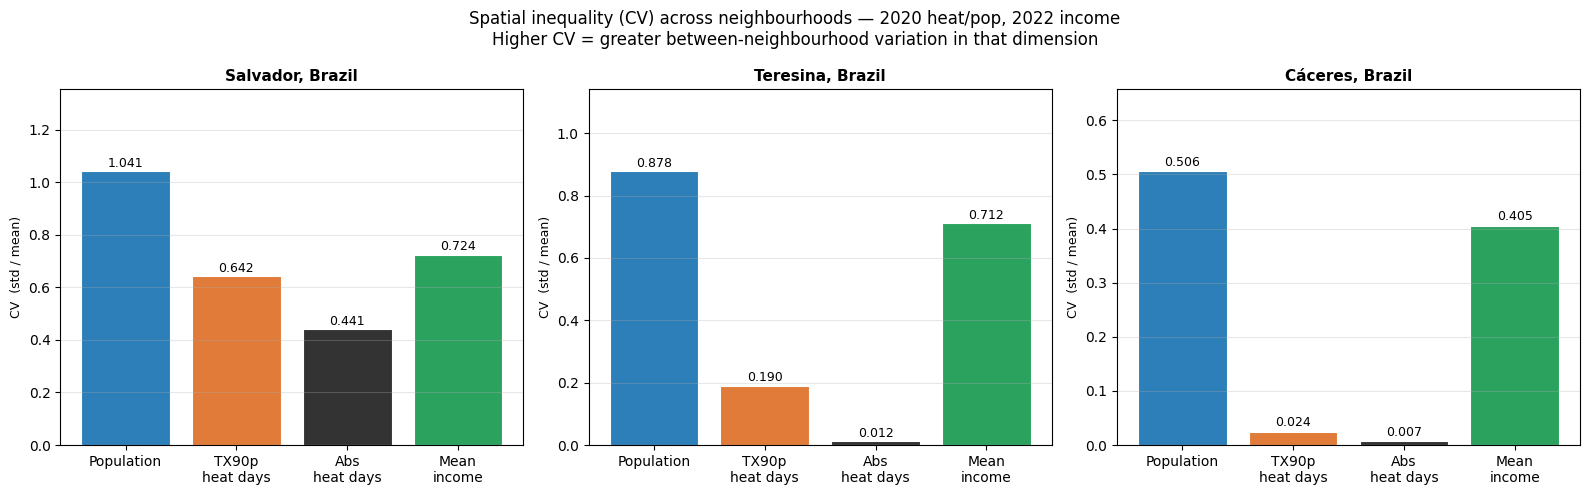

In [6]:
merged = {}
for c in CITY_KEYS:
    df = heat_tables[c].merge(
        income[c][['name', 'mean_income', 'n_sectors', 'std_income']],
        on='name', how='left'
    ).dropna(subset=['mean_income']).reset_index(drop=True)
    merged[c] = df
    print(f"{CITIES[c]['label']:12s}  {len(df)} neighbourhoods in merged table")

# ---- CV table ----------------------------------------------------------------
cv_rows = []
for c in CITY_KEYS:
    df = merged[c]
    cv_rows.append({
        'City':              CITIES[c]['label'],
        'CV: population':    cv(df['population']),
        'CV: TX90p hd':      cv(df['tx90p_hd']),
        'CV: abs hd':        cv(df['abs_hd']),
        'CV: mean income':   cv(df['mean_income']),
        'N nbhd':            len(df),
    })

cv_df = pd.DataFrame(cv_rows).set_index('City')
cv_cols = ['CV: population', 'CV: TX90p hd', 'CV: abs hd', 'CV: mean income']
display(
    cv_df.style
    .format({c: '{:.3f}' for c in cv_cols} | {'N nbhd': '{:.0f}'})
    .background_gradient(subset=cv_cols, cmap='YlOrRd', axis=None)
    .set_caption(f'Coefficient of variation across neighbourhoods — {DIAG_YEAR} heat/pop, 2022 income')
    .set_table_styles(table_styles)
)

# ---- CV bar chart ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle(
    f'Spatial inequality (CV) across neighbourhoods — {DIAG_YEAR} heat/pop, 2022 income\n'
    'Higher CV = greater between-neighbourhood variation in that dimension',
    fontsize=12,
)

var_labels  = ['Population', 'TX90p\nheat days', 'Abs\nheat days', 'Mean\nincome']
var_keys    = ['CV: population', 'CV: TX90p hd', 'CV: abs hd', 'CV: mean income']
bar_colors  = ['#2c7fb8', '#e07b39', '#333333', '#2ca25f']

for ax, c in zip(axes, CITY_KEYS):
    vals = [cv_df.loc[CITIES[c]['label'], k] for k in var_keys]
    bars = ax.bar(var_labels, vals, color=bar_colors, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(CITIES[c]['label'], fontsize=11, fontweight='bold')
    ax.set_ylabel('CV  (std / mean)', fontsize=9)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 3b — Income distribution and income–heat correlation per city

For the adaptive capacity argument to hold, income does **not** need to correlate
negatively with heat days (poorer areas do not need to be hotter).  Income mediates
coping capacity *when heat occurs*, so the two dimensions can be spatially independent
and the composite index still captures something neither variable captures alone.

However, the direction and strength of the correlation matters for interpretation:
a positive correlation (richer = hotter) would mean that income weighting *reduces*
the apparent burden of the hottest neighbourhoods, which runs counter to the intended
policy logic and should be flagged.

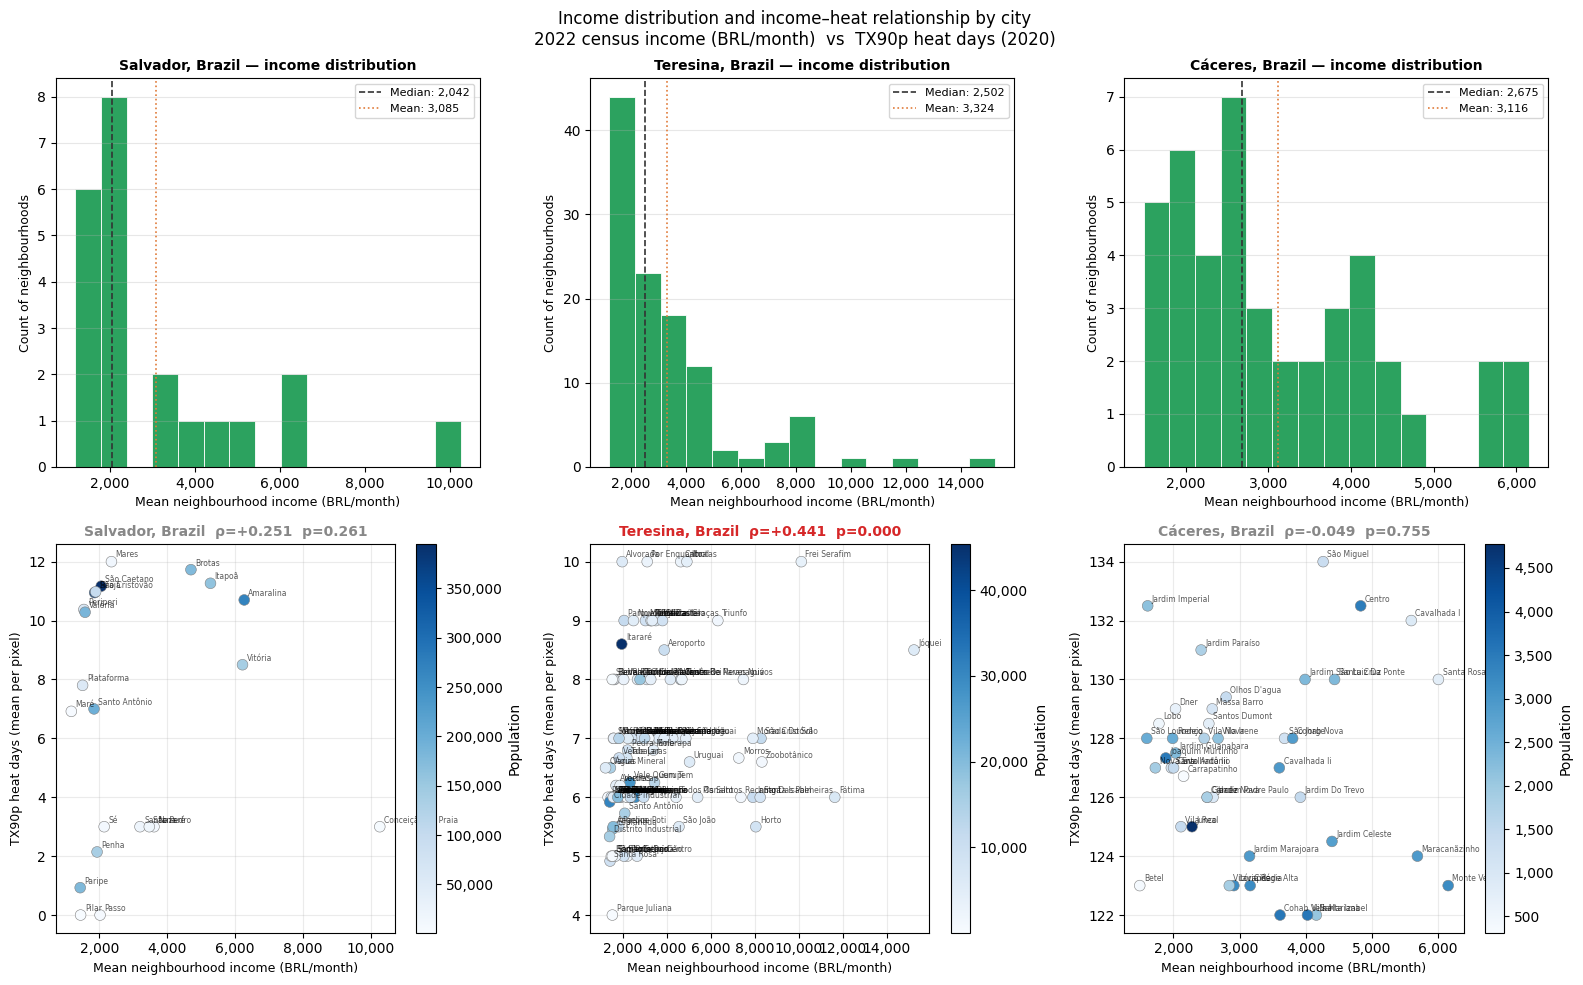

,ρ income vs TX90p hd,p-value,ρ income vs population,ρ income vs TX90p pd
City,,,,
"Salvador, Brazil",+0.251,0.2608,+0.050,+0.097
"Teresina, Brazil",+0.441,0.0000,-0.154,-0.078
"Cáceres, Brazil",-0.049,0.7553,+0.265,+0.270


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Income distribution and income–heat relationship by city\n'
    '2022 census income (BRL/month)  vs  TX90p heat days (2020)',
    fontsize=12,
)

rho_rows = []
for col, c in enumerate(CITY_KEYS):
    df    = merged[c]
    label = CITIES[c]['label']

    # ---- Row 0: income distribution -----------------------------------------
    ax = axes[0][col]
    ax.hist(df['mean_income'], bins=15, color='#2ca25f', edgecolor='white', linewidth=0.6)
    ax.axvline(df['mean_income'].median(), color='#333333', linewidth=1.2,
               linestyle='--', label=f'Median: {df["mean_income"].median():,.0f}')
    ax.axvline(df['mean_income'].mean(), color='#e07b39', linewidth=1.2,
               linestyle=':', label=f'Mean: {df["mean_income"].mean():,.0f}')
    ax.set_xlabel('Mean neighbourhood income (BRL/month)', fontsize=9)
    ax.set_ylabel('Count of neighbourhoods', fontsize=9)
    ax.set_title(f'{label} — income distribution', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # ---- Row 1: income vs TX90p heat days ------------------------------------
    ax = axes[1][col]
    rho, p = spearmanr(df['mean_income'], df['tx90p_hd'])
    rho_rows.append({'City': label, 'ρ income vs TX90p hd': rho, 'p-value': p,
                     'ρ income vs population': spearmanr(df['mean_income'], df['population'])[0],
                     'ρ income vs TX90p pd':   spearmanr(df['mean_income'], df['tx90p_pd'])[0]})

    sc = ax.scatter(df['mean_income'], df['tx90p_hd'],
                    c=df['population'], cmap='Blues', s=60,
                    edgecolors='grey', linewidth=0.4, zorder=3)
    plt.colorbar(sc, ax=ax, label='Population',
                 format=mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    for _, row in df.iterrows():
        ax.annotate(row['name'], (row['mean_income'], row['tx90p_hd']),
                    fontsize=5.5, alpha=0.65, xytext=(3, 3),
                    textcoords='offset points')
    color = '#d62728' if rho > 0.3 else '#1f77b4' if rho < -0.3 else '#888888'
    ax.set_title(f'{label}  ρ={rho:+.3f}  p={p:.3f}',
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Mean neighbourhood income (BRL/month)', fontsize=9)
    ax.set_ylabel('TX90p heat days (mean per pixel)', fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# ---- Correlation summary table ----------------------------------------------
rho_df = pd.DataFrame(rho_rows).set_index('City')
rho_cols = ['ρ income vs TX90p hd', 'ρ income vs population', 'ρ income vs TX90p pd']
display(
    rho_df.style
    .format({'ρ income vs TX90p hd': '{:+.3f}',
             'ρ income vs population': '{:+.3f}',
             'ρ income vs TX90p pd':   '{:+.3f}',
             'p-value': '{:.4f}'})
    .background_gradient(subset=rho_cols, cmap='RdYlGn', vmin=-1, vmax=1, axis=None)
    .set_caption('Spearman rank correlations between income and heat/population variables')
    .set_table_styles(table_styles)
)

## Section 4 — Revised heat risk function with adaptive capacity

### Definition

The revised heat risk index for each neighbourhood $i$ in city $c$ is:

$$\text{HRI}_i = \text{TX90p\_person\_days}_i \times V_i$$

where the **vulnerability score** $V_i$ inverts the rank-normalised income:

$$V_i = 1 - \frac{\text{rank}(\text{income}_i) - 1}{n - 1}$$

Rank 1 = lowest income (most vulnerable, $V = 1.0$); rank $n$ = highest income
($V = 0.0$).  Rank-based normalisation (Method B from notebook 10) is used throughout
because it is robust to the income outliers present in all three cities.

### Policy interpretation

| Component | What it captures |
|-----------|------------------|
| TX90p person-days | Relative heat exposure × population (how many person-days of above-baseline heat) |
| Vulnerability score | Inverse of income rank — proxy for adaptive capacity (AC affordability, housing quality, healthcare access) |
| HRI product | Compound burden: exposure that meets low capacity to cope |

Neighbourhoods rank differently under HRI vs unweighted person-days when income and
heat exposure are spatially independent — the composite surfaces places that the
heat-only map misses.

In [8]:
def build_hri(df):
    """Add vulnerability score and HRI to a merged neighbourhood dataframe."""
    n = len(df)
    df = df.copy()
    df['income_rank_asc']    = df['mean_income'].rank(ascending=True, method='average')
    df['vulnerability']      = (df['income_rank_asc'] - 1) / (n - 1)
    df['hri']                = df['tx90p_pd'] * df['vulnerability']
    df['rank_tx90p_pd']      = df['tx90p_pd'].rank(ascending=False, method='min').astype(int)
    df['rank_hri']           = df['hri'].rank(ascending=False, method='min').astype(int)
    df['rank_shift']         = df['rank_tx90p_pd'] - df['rank_hri']
    return df

hri_tables = {c: build_hri(merged[c]) for c in CITY_KEYS}

# ---- Summary tables per city ------------------------------------------------
for c in CITY_KEYS:
    df    = hri_tables[c]
    label = CITIES[c]['label']
    display(
        df[['name', 'mean_income', 'tx90p_pd', 'vulnerability',
            'hri', 'rank_tx90p_pd', 'rank_hri', 'rank_shift']]
        .sort_values('rank_hri')
        .style
        .format({
            'mean_income':   '{:.0f}',
            'tx90p_pd':      '{:,.0f}',
            'vulnerability': '{:.3f}',
            'hri':           '{:,.0f}',
            'rank_tx90p_pd': '{:.0f}',
            'rank_hri':      '{:.0f}',
            'rank_shift':    '{:+.0f}',
        })
        .background_gradient(subset=['vulnerability'], cmap='RdYlGn_r', vmin=0, vmax=1)
        .background_gradient(subset=['rank_shift'], cmap='RdYlGn_r',
                             vmin=-len(df), vmax=len(df))
        .set_caption(f'{label} — HRI rankings  (rank_shift: positive = moves up under HRI)')
        .set_table_styles(table_styles)
    )

,name,mean_income,tx90p_pd,vulnerability,hri,rank_tx90p_pd,rank_hri,rank_shift
0,Amaralina,6270,"2,845,064",0.952,"2,709,585",3,1,+2
6,São Caetano,2059,"4,303,580",0.524,"2,254,256",1,2,-1
3,Itapoã,5277,"1,982,070",0.857,"1,698,917",5,3,+2
1,Brotas,4701,"2,078,214",0.810,"1,682,363",4,4,+0
4,Pirajá,1865,"4,006,178",0.333,"1,335,393",2,5,-3
21,Vitória,6220,"1,167,467",0.905,"1,056,280",9,6,+3
5,Santo Antônio,1847,"1,562,627",0.286,"446,465",7,7,+0
7,São Cristovão,1895,"1,161,960",0.381,"442,652",10,8,+2
20,Valéria,1584,"1,814,978",0.238,"432,138",6,9,-3
13,Penha,1937,"445,397",0.429,"190,884",13,10,+3


,name,mean_income,tx90p_pd,vulnerability,hri,rank_tx90p_pd,rank_hri,rank_shift
84,Itararé,1949,"404,299",0.342,"138,409",1,1,+0
3,Mocambinho,2570,"177,042",0.514,"90,913",2,2,+0
57,São Cristóvão,8286,"82,099",0.964,"79,141",17,3,+14
54,Vale Quem Tem,2325,"170,975",0.459,"78,556",4,4,+0
96,Parque Piauí,2782,"142,742",0.550,"78,444",5,5,+0
25,Cristo Rei,4635,"93,083",0.820,"76,312",12,6,+6
62,Aeroporto,3882,"88,534",0.757,"66,998",15,7,+8
34,Iningá,7916,"66,624",0.937,"62,423",26,8,+18
9,Centro,4638,"75,099",0.829,"62,244",21,9,+12
23,Macaúba,3803,"79,372",0.739,"58,635",18,10,+8


,name,mean_income,tx90p_pd,vulnerability,hri,rank_tx90p_pd,rank_hri,rank_shift
36,Centro,4832,"456,557",0.905,"413,076",2,1,+1
13,Monte Verde,6155,"392,824",1.000,"392,824",6,2,+4
10,Maracanãzinho,5690,"364,023",0.952,"346,689",11,3,+8
11,Vila Mariana,4027,"433,522",0.786,"340,624",4,4,+0
8,Jardim Celeste,4397,"351,850",0.857,"301,586",13,5,+8
12,Cohab Velha,3612,"433,522",0.667,"289,014",4,6,-2
33,Santa Cruz,4436,"301,559",0.881,"265,660",16,7,+9
41,Cohab Nova,3802,"370,925",0.714,"264,947",10,8,+2
14,Cidade Alta,3160,"392,824",0.619,"243,177",6,9,-3
16,Cavalhada Ii,3601,"375,066",0.643,"241,114",9,10,-1


## Section 4b — Rank shift visualisation across all three cities

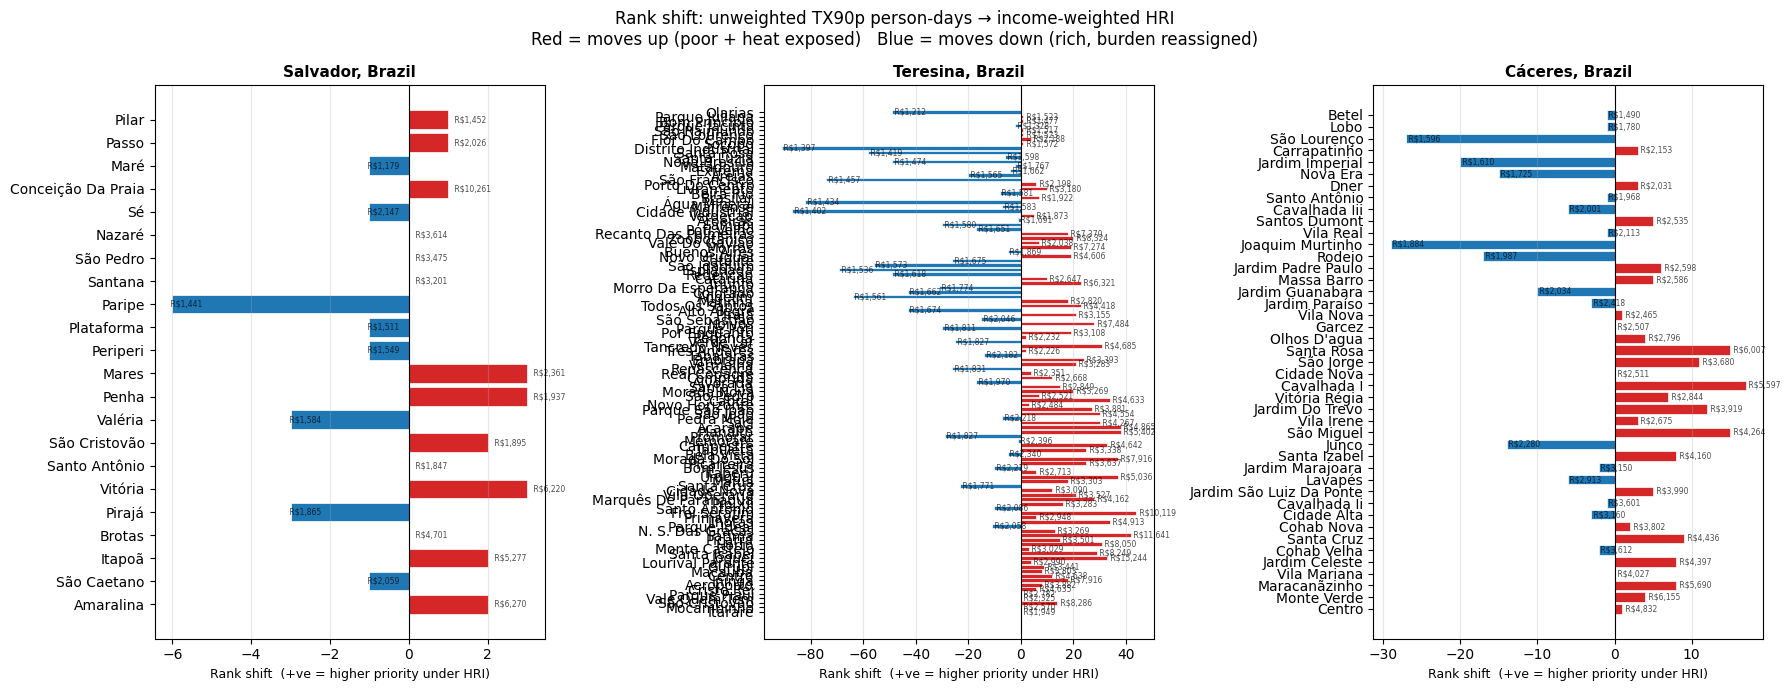

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    'Rank shift: unweighted TX90p person-days → income-weighted HRI\n'
    'Red = moves up (poor + heat exposed)   Blue = moves down (rich, burden reassigned)',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    df     = hri_tables[c].sort_values('rank_hri')
    label  = CITIES[c]['label']
    colors = ['#d62728' if s > 0 else '#1f77b4' if s < 0 else '#aaaaaa'
              for s in df['rank_shift']]
    ax.barh(df['name'], df['rank_shift'], color=colors,
            edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Rank shift  (+ve = higher priority under HRI)', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    # Annotate income for context
    for _, row in df.iterrows():
        x_pos = row['rank_shift'] + (0.1 if row['rank_shift'] >= 0 else -0.1)
        ax.text(x_pos, row['name'],
                f" R${row['mean_income']:,.0f}",
                va='center', fontsize=5.5, alpha=0.7)

plt.tight_layout()
plt.show()

## Section 5 — Concrete implementation recommendations

### 5.1 Recommended index formulation

Use the **rank-based vulnerability score (Method B)** throughout:

```
V_i  = 1 − (rank(income_i) − 1) / (n − 1)     # rank 1 = poorest
HRI_i = TX90p_person_days_i × V_i
```

**Why rank-based over min-max (Method A):**
- Robust to the high-income outliers present in all three cities
  (Salvador max: R$61 671; Teresina max varies; Cáceres max: R$9 139)
- Guarantees a smooth, equally-spaced vulnerability gradient regardless of
  the income distribution shape
- Min-max collapses the majority of neighbourhoods into a narrow vulnerability
  band when one outlier dominates the range

### 5.2 Recommended use cases per city

The HRI should be used as a **relative within-city priority ranking**, not as an
absolute measure of harm or a cross-city comparison.  Appropriate uses:

- Prioritising cooling infrastructure deployment (e.g. public cooling centres,
  shade structures, green corridors) within a city
- Targeting health outreach and early-warning communications during heat events
- Identifying neighbourhoods where housing retrofit programmes (insulation,
  ventilation) would have the greatest compound benefit

### 5.3 What the index does not do

- It does not rank cities against each other (TX90p is a within-city relative
  threshold; income data is not cross-nationally comparable)
- It does not capture individual-level vulnerability (elderly residents, outdoor
  workers, people with pre-existing conditions) — neighbourhood-level income is
  a group proxy
- It does not account for access to public cooling infrastructure that already
  exists in some neighbourhoods

In [10]:
# ---- Top-3 priority neighbourhoods per city under HRI vs unweighted ----------
print("Top 5 priority neighbourhoods under each metric\n")
print(f"{'City':<12}  {'Rank':<5}  {'Neighbourhood':<25}  "
      f"{'TX90p pd rank':<15}  {'HRI rank':<10}  {'Shift':<8}  {'Income (BRL)':<15}  {'Vulnerability'}")
print("-" * 110)
for c in CITY_KEYS:
    df = hri_tables[c].sort_values('rank_hri').head(5)
    for _, row in df.iterrows():
        print(f"{CITIES[c]['label']:<12}  {row['rank_hri']:<5.0f}  "
              f"{row['name']:<25}  {row['rank_tx90p_pd']:<15.0f}  "
              f"{row['rank_hri']:<10.0f}  {row['rank_shift']:<+8.0f}  "
              f"{row['mean_income']:<15,.0f}  {row['vulnerability']:.3f}")
    print()

Top 5 priority neighbourhoods under each metric

City          Rank   Neighbourhood              TX90p pd rank    HRI rank    Shift     Income (BRL)     Vulnerability
--------------------------------------------------------------------------------------------------------------
Salvador, Brazil  1      Amaralina                  3                1           +2        6,270            0.952
Salvador, Brazil  2      São Caetano                1                2           -1        2,059            0.524
Salvador, Brazil  3      Itapoã                     5                3           +2        5,277            0.857
Salvador, Brazil  4      Brotas                     4                4           +0        4,701            0.810
Salvador, Brazil  5      Pirajá                     2                5           -3        1,865            0.333

Teresina, Brazil  1      Itararé                    1                1           +0        1,949            0.342
Teresina, Brazil  2      Mocambinho  

## Section 6 — Shortcomings, assumptions, and future directions

### 6.1 Income as adaptive capacity proxy

Income is used here as a proxy for the capacity to cope with heat.  It correlates
with many of the factors that matter — AC ownership, housing insulation quality,
healthcare access, ability to take time off outdoor work — but it is not a direct
measure of any of them.  Key gaps:

- **Outdoor employment share:** a neighbourhood with moderate income but high
  outdoor labour exposure (construction, agriculture, street vending) faces greater
  heat risk than income alone implies
- **Age structure:** elderly residents are physiologically more vulnerable regardless
  of income; the index does not capture age distribution
- **Pre-existing health conditions:** cardiovascular and respiratory disease rates,
  which mediate heat mortality, are not reflected in income at this scale
- **Existing cooling infrastructure:** some low-income neighbourhoods may have
  better access to public cooling centres or green space than others at similar
  income levels

### 6.2 Aggregation limitations

The centroid-based aggregation from census sectors to neighbourhood boundaries
carries the following known errors (documented in detail in notebook 10):

- **MAUP boundary straddling:** sectors crossing neighbourhood boundaries are
  assigned wholly to one side by their centroid
- **Simple mean, no population weights:** each sector is equally weighted
  regardless of how many residents it contains; a population-weighted mean
  would require household counts not available in this GeoJSON
- **Temporal mismatch:** neighbourhood boundaries are from the 2010 IBGE GeoPackage;
  income is from the 2022 census
- **Low coverage in Cáceres:** with ~5 sectors per neighbourhood, the simple mean
  is highly sensitive to individual sector values; income estimates for Cáceres
  should be treated as indicative

### 6.3 Composite index assumptions

- **Equal weighting:** the index multiplies person-days by vulnerability at full
  weight.  This implicitly assumes heat burden and income vulnerability contribute
  equally to overall risk.  No empirical basis exists for this 50/50 split; a
  sensitivity analysis varying the exponent (e.g. `pd × V^α` for α ∈ [0.5, 2.0])
  is advisable before policy use
- **Multiplicative form:** the index is zero for the richest neighbourhood regardless
  of its heat burden.  An additive form avoids this but blends incommensurable units;
  notebook 10 showed the two forms produce notably different rankings
  (ρ = 0.69 for Method B)
- **Within-city only:** TX90p is a relative threshold (roughly top 10% of days per
  location); it cannot be used to compare absolute heat burden between cities

### 6.4 Scaling and cross-national comparability ⚠️

**This is the most significant limitation of the current approach.**

The `renda_responsavel` field is a product of the Brazilian IBGE 2022 census.  It
exists at this spatial resolution and consistency for Brazil only.  Extending the
income-weighted HRI to cities outside Brazil faces two distinct problems:

1. **Data availability:** equivalent sub-city income data at census sector resolution
   does not exist for most cities in the Global South, where heat risk is highest.
   Countries that do publish census income data vary enormously in definition
   (household income, per-capita income, consumption expenditure), spatial unit, and
   vintage.

2. **Comparability:** even where income data exists, a given BRL value implies
   different adaptive capacity than the equivalent USD or NGN value in another country,
   due to differences in purchasing power, local energy prices, housing stock norms,
   and the income threshold at which AC becomes accessible.

The index as constructed **cannot be used to compare vulnerability rankings across
countries**, and should not be presented as a globally applicable method without
substantial methodological revision.

### 6.5 Future directions

**A. Global gridded GDP as a scalable substitute**

Chen et al. (2022, *Scientific Data*, DOI: 10.1038/s41597-022-01322-5) provide a
global 1 km × 1 km gridded real GDP dataset covering 175 countries at annual
timesteps from 1992 to 2019, derived from calibrated DMSP/OLS and NPP/VIIRS
nighttime light data.  The dataset is available on Figshare
(DOI: 10.6084/m9.figshare.17004523).

This is the most promising near-term path to a globally scalable adaptive capacity
layer because:
- The 1 km resolution matches the existing heat and population grids exactly
- The temporal coverage (1992–2019) overlaps with the heat data
- It covers 175 countries, including all three study cities
- The same dataset includes **electricity consumption per pixel**, which is arguably
  a more direct proxy for AC access than GDP

*Key caveats for this dataset:*
- GDP measures economic output, not household welfare; industrial areas inflate
  values without implying resident adaptive capacity
- Nightlight-based methods systematically underestimate economic activity in
  informal settlements — precisely the areas most at risk
- The GDP–adaptive capacity relationship varies across countries; validation
  against the Brazilian census income data used here would be a necessary
  first step before applying the GDP layer globally
- Coverage ends at 2019; a post-COVID update is not yet available

**B. Recommended validation workflow**

For the three Brazilian cities, the Chen et al. GDP layer can be tested directly
against the census income aggregation: aggregate the 1 km GDP grid to the same 22/112/43
neighbourhood boundaries and compute Spearman ρ between GDP-per-pixel and
`renda_responsavel`-derived income.  A high correlation would support extending
the GDP-based vulnerability index to cities outside Brazil.

**C. Additional adaptive capacity variables to explore**

- NDVI / green space access per neighbourhood (available via Landsat/Sentinel)
- Age structure (% population over 65) from census data
- Housing informality / slum delineation (UN-Habitat data for some cities)
- DHS (Demographic and Health Survey) asset indices for non-census contexts

## Summary

This notebook extends the income-weighted heat risk framework from Salvador (notebook 10)
to all three study cities, using 2022 IBGE census income as a proxy for adaptive
capacity.  Key results and recommendations are drawn together in the table below.

In [11]:
# ---- Cross-city summary table -----------------------------------------------
summary_rows = []
for c in CITY_KEYS:
    df    = hri_tables[c]
    rho_hd, p_hd = spearmanr(df['mean_income'], df['tx90p_hd'])
    # Max rank shift (most moved-up neighbourhood)
    top_mover = df.loc[df['rank_shift'].idxmax()]
    summary_rows.append({
        'City':                      CITIES[c]['label'],
        'Neighbourhoods':            len(df),
        'CV income':                 cv(df['mean_income']),
        'CV TX90p hd':               cv(df['tx90p_hd']),
        'ρ income–TX90p hd':         rho_hd,
        'p-value':                   p_hd,
        'Max rank shift':            int(df['rank_shift'].max()),
        'Neighbourhood (max shift)': top_mover['name'],
        'Mean sectors/nbhd':         df['n_sectors'].mean(),
    })

summary_df = pd.DataFrame(summary_rows).set_index('City')
display(
    summary_df.style
    .format({
        'Neighbourhoods':   '{:.0f}',
        'CV income':        '{:.3f}',
        'CV TX90p hd':      '{:.3f}',
        'ρ income–TX90p hd': '{:+.3f}',
        'p-value':          '{:.4f}',
        'Max rank shift':   '{:+d}',
        'Mean sectors/nbhd': '{:.1f}',
    })
    .background_gradient(subset=['CV income', 'CV TX90p hd'], cmap='YlOrRd', axis=None)
    .background_gradient(subset=['ρ income–TX90p hd'], cmap='RdYlGn', vmin=-1, vmax=1)
    .background_gradient(subset=['Mean sectors/nbhd'], cmap='RdYlGn', vmin=1, vmax=210)
    .set_caption('Cross-city summary — heat risk with adaptive capacity')
    .set_table_styles(table_styles)
)

,Neighbourhoods,CV income,CV TX90p hd,ρ income–TX90p hd,p-value,Max rank shift,Neighbourhood (max shift),Mean sectors/nbhd
City,,,,,,,,
"Salvador, Brazil",22,0.724,0.642,+0.251,0.2608,+3,Mares,204.0
"Teresina, Brazil",112,0.712,0.190,+0.441,0.0000,+44,Frei Serafim,13.3
"Cáceres, Brazil",43,0.405,0.024,-0.049,0.7553,+17,Cavalhada I,4.7
